In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print(df.shape)
df.head(10)

(150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [ ]:
print(df.info())
print('\nNull values:', df.isnull().sum().sum())
print('\nClass distribution:\n', df['species_name'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Null values: 0

Class distribution:
 species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


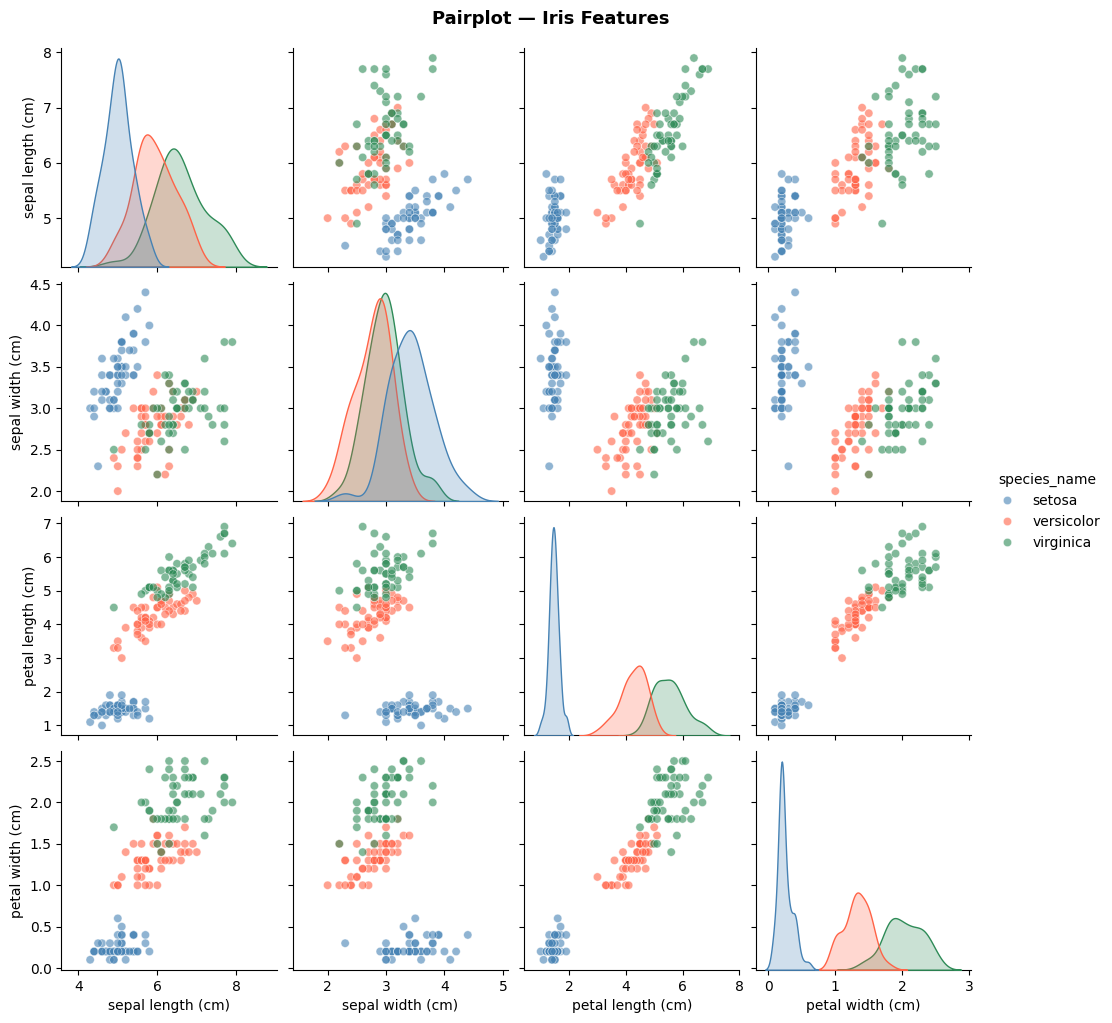

In [ ]:
# pairplot
plot_df = df[iris.feature_names + ['species_name']]
sns.pairplot(plot_df, hue='species_name',
             palette={'setosa': 'steelblue', 'versicolor': 'tomato', 'virginica': 'seagreen'},
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot — Iris Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

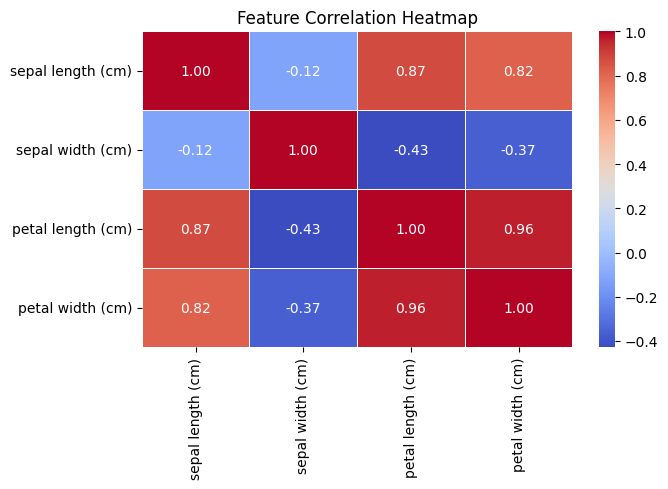

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Train: (120, 4) | Test: (30, 4)


In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

# macro ROC-AUC (one-vs-rest)
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {auc:.4f}  (macro, OvR)')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=labels))

Accuracy : 0.9333
ROC-AUC  : 0.9967  (macro, OvR)

Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



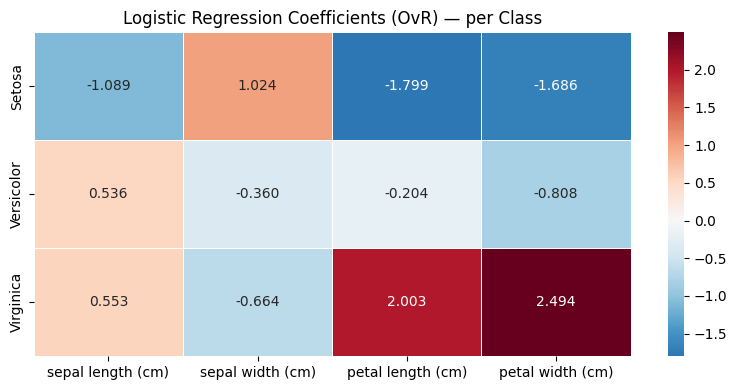

In [ ]:
# coefficient heatmap — one row per class
coef_df = pd.DataFrame(model.coef_, columns=iris.feature_names,
                        index=['Setosa', 'Versicolor', 'Virginica'])

plt.figure(figsize=(8, 4))
sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Logistic Regression Coefficients (OvR) — per Class')
plt.tight_layout()
plt.show()